In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("/content/data_with_clusters.csv")
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76518 entries, 0 to 76517
Data columns (total 40 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   id                                              76518 non-null  float64
 1   Marital status                                  76518 non-null  int64  
 2   Application mode                                76518 non-null  float64
 3   Application order                               76518 non-null  float64
 4   Course                                          76518 non-null  float64
 5   Daytime/evening attendance                      76518 non-null  int64  
 6   Previous qualification                          76518 non-null  int64  
 7   Previous qualification (grade)                  76518 non-null  float64
 8   Nacionality                                     76518 non-null  int64  
 9   Mother's qualification                 

,id,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,KMeans_Cluster,DBSCAN_Cluster
0,0.000000,0,0.000000,0.285714,0.556668,0,0,0.391667,0,0.000000,...,0.458333,0.444444,0.566967,0,0.406977,0.311111,0.803170,Graduate,2,0
1,0.000013,0,0.307692,0.285714,0.556668,0,0,0.375000,0,0.418605,...,0.625000,0.000000,0.000000,0,0.406977,0.311111,0.803170,Dropout,2,0
2,0.000026,0,0.307692,0.571429,0.566088,0,0,0.575000,0,0.046512,...,0.000000,0.000000,0.000000,0,1.000000,0.244444,0.414795,Dropout,1,0
3,0.000039,0,0.000000,0.857143,0.710921,0,0,0.475000,0,0.418605,...,0.791667,0.518519,0.597391,0,0.406977,0.311111,0.803170,Enrolled,2,0
4,0.000052,0,0.000000,0.571429,0.710921,0,0,0.491667,0,0.418605,...,0.875000,0.444444,0.606199,0,0.000000,0.755556,0.578600,Graduate,2,0


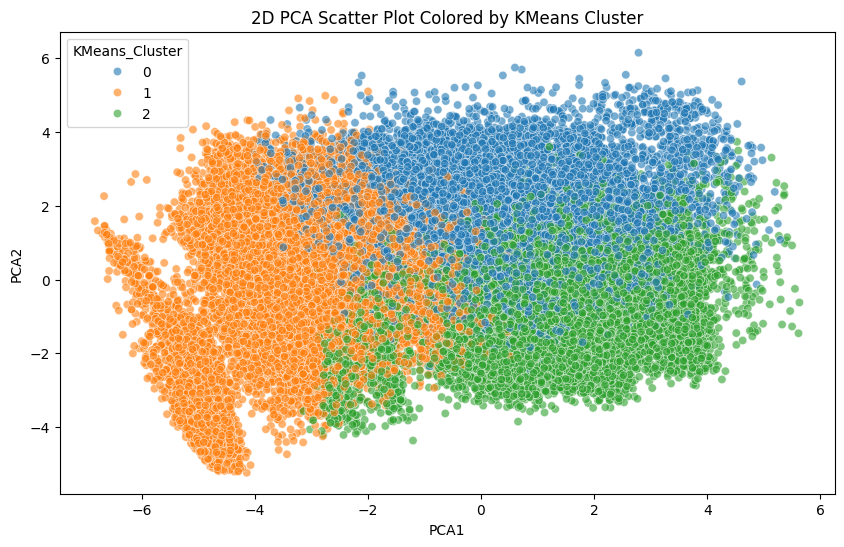

In [2]:

features = df.drop(columns=["id", "Target", "KMeans_Cluster", "DBSCAN_Cluster"])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

pca = PCA(n_components=2)
pca_2d = pca.fit_transform(scaled_features)

df['PCA1'] = pca_2d[:, 0]
df['PCA2'] = pca_2d[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="KMeans_Cluster", palette="tab10", alpha=0.6)
plt.title("2D PCA Scatter Plot Colored by KMeans Cluster")
plt.show()


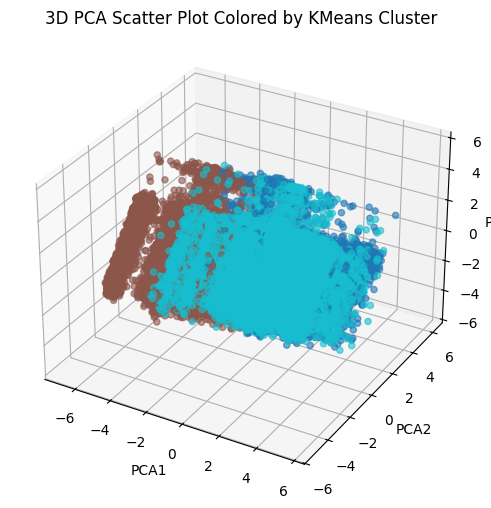

In [3]:

from mpl_toolkits.mplot3d import Axes3D
pca_3d = PCA(n_components=3).fit_transform(scaled_features)
df["PCA3"] = pca_3d[:, 2]

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['PCA1'], df['PCA2'], df['PCA3'], c=df['KMeans_Cluster'], cmap='tab10', alpha=0.6)
ax.set_title("3D PCA Scatter Plot Colored by KMeans Cluster")
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
plt.show()


/tmp/ipython-input-4-2669485039.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="KMeans_Cluster", palette="Set2")


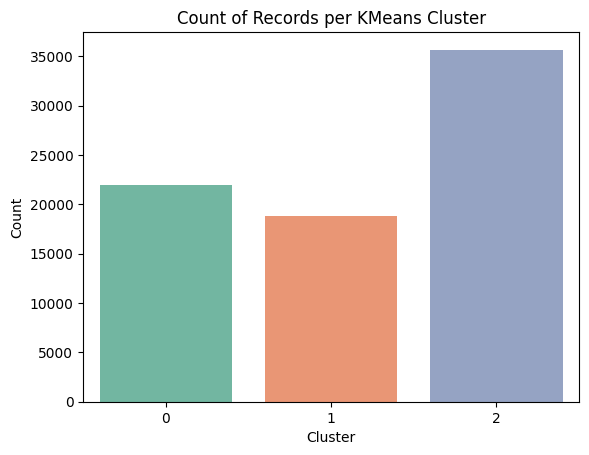

In [4]:

sns.countplot(data=df, x="KMeans_Cluster", palette="Set2")
plt.title("Count of Records per KMeans Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()


/tmp/ipython-input-5-3733104044.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="KMeans_Cluster", y=feature, palette="Pastel1")


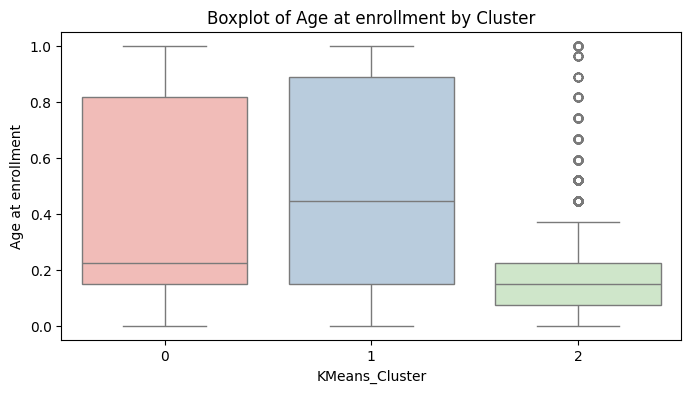

/tmp/ipython-input-5-3733104044.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="KMeans_Cluster", y=feature, palette="Pastel1")


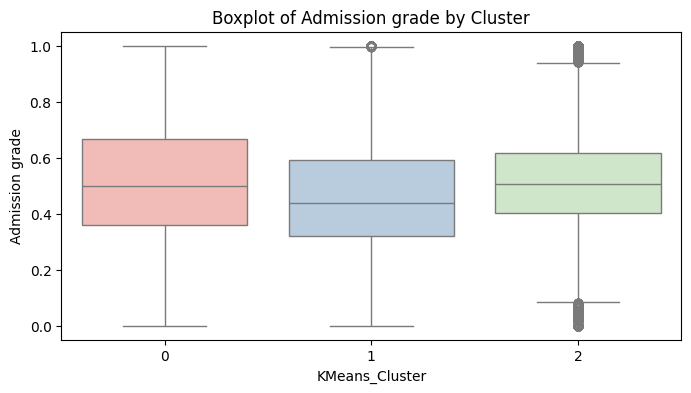

/tmp/ipython-input-5-3733104044.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="KMeans_Cluster", y=feature, palette="Pastel1")


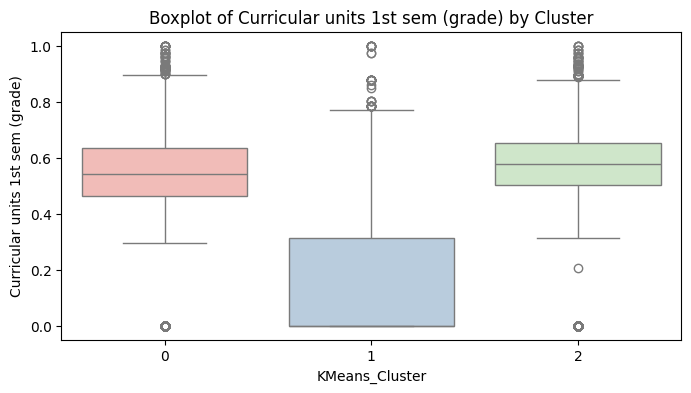

/tmp/ipython-input-5-3733104044.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="KMeans_Cluster", y=feature, palette="Pastel1")


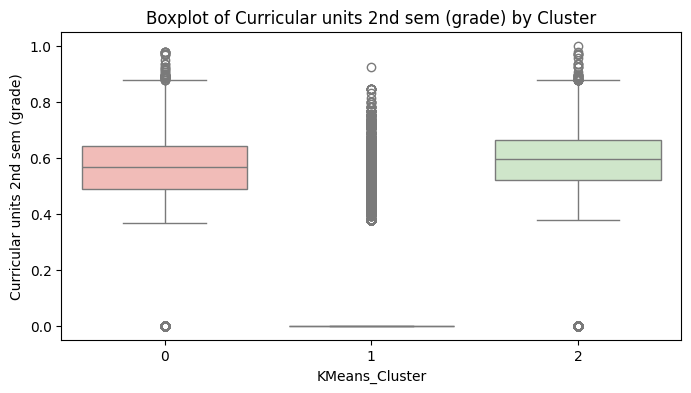

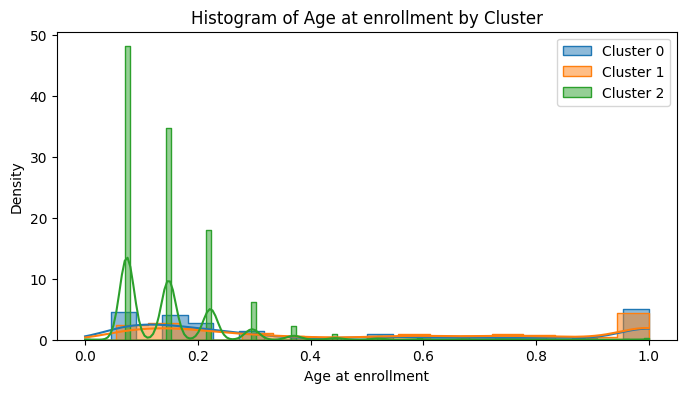

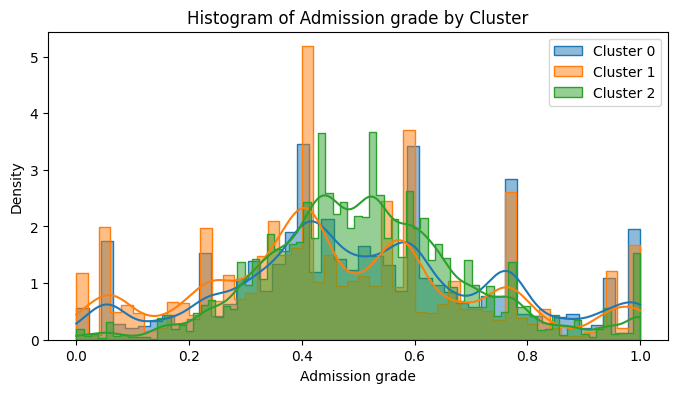

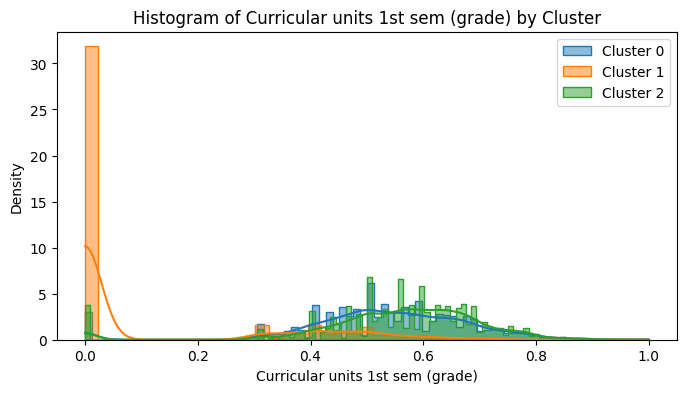

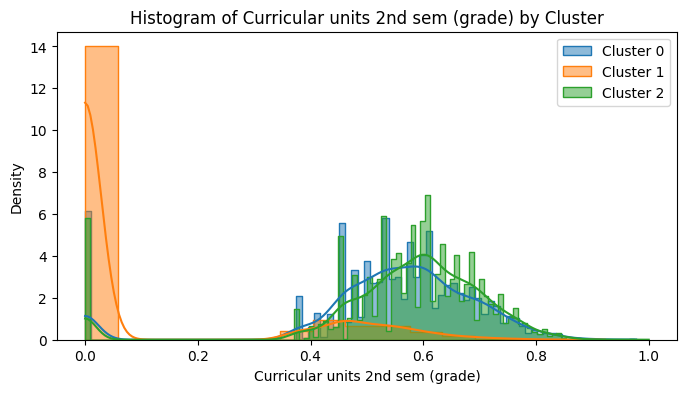

In [5]:

key_numeric = ['Age at enrollment', 'Admission grade',
               'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)']

for feature in key_numeric:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x="KMeans_Cluster", y=feature, palette="Pastel1")
    plt.title(f'Boxplot of {feature} by Cluster')
    plt.show()

for feature in key_numeric:
    plt.figure(figsize=(8, 4))
    for cluster_id in sorted(df["KMeans_Cluster"].unique()):
        sns.histplot(df[df["KMeans_Cluster"] == cluster_id][feature], label=f'Cluster {cluster_id}',
                     kde=True, element="step", stat="density", common_norm=False)
    plt.title(f'Histogram of {feature} by Cluster')
    plt.legend()
    plt.show()


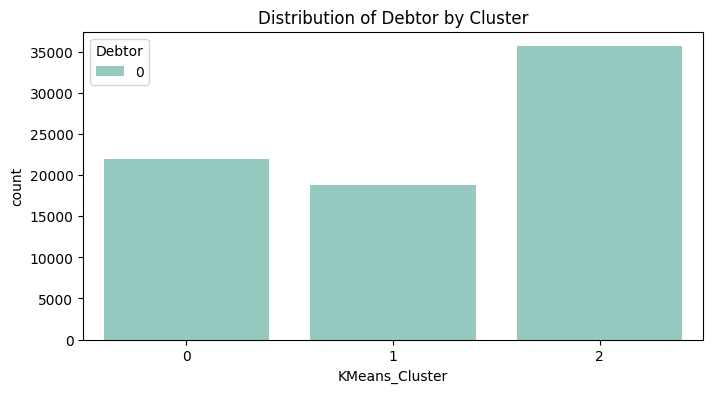

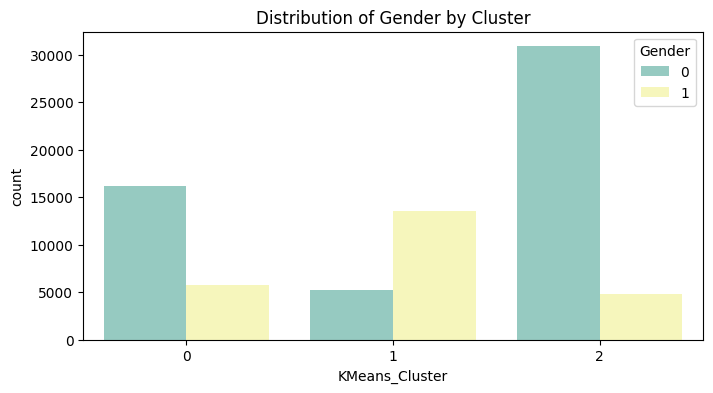

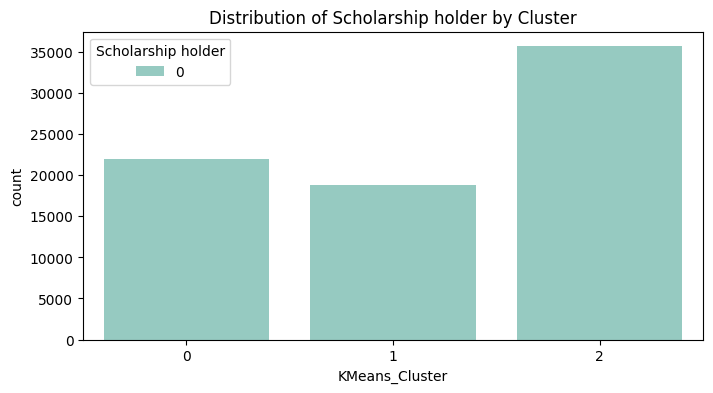

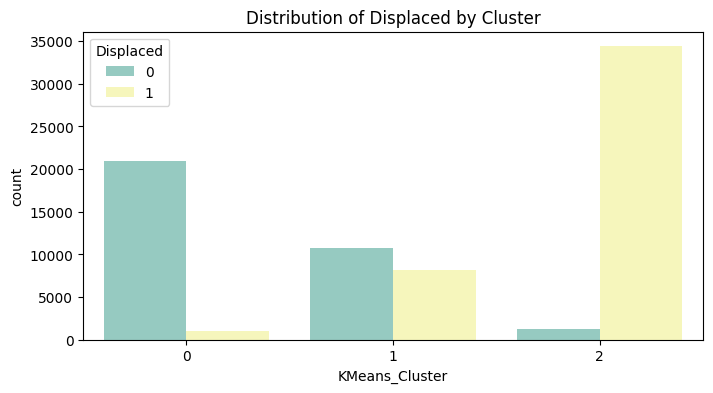

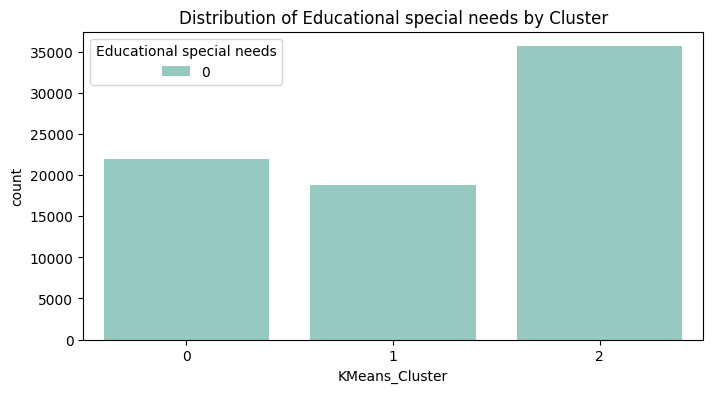

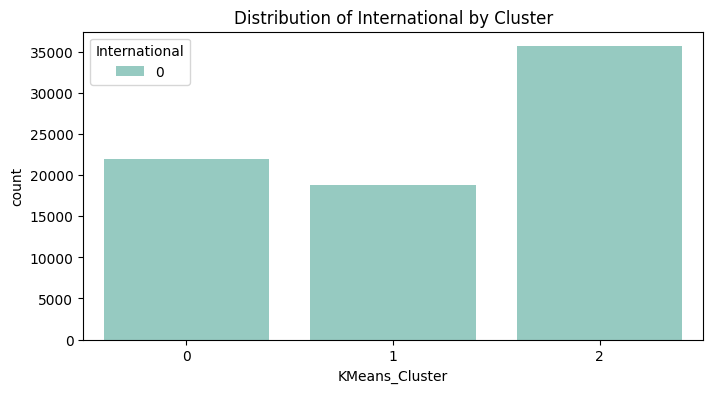

In [6]:

binary_categorical = ['Debtor', 'Gender', 'Scholarship holder', 'Displaced',
                      'Educational special needs', 'International']

for feature in binary_categorical:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x="KMeans_Cluster", hue=feature, palette="Set3")
    plt.title(f'Distribution of {feature} by Cluster')
    plt.show()


In [8]:

profile = df.groupby("KMeans_Cluster")[key_numeric + binary_categorical].agg(['mean', 'median'])
profile.columns = ['_'.join(col) for col in profile.columns]
profile.reset_index(inplace=True)
profile.to_csv("/content/cluster_profile_summary.csv", index=False)
profile


,KMeans_Cluster,Age at enrollment_mean,Age at enrollment_median,Admission grade_mean,Admission grade_median,Curricular units 1st sem (grade)_mean,Curricular units 1st sem (grade)_median,Curricular units 2nd sem (grade)_mean,Curricular units 2nd sem (grade)_median,Debtor_mean,...,Gender_mean,Gender_median,Scholarship holder_mean,Scholarship holder_median,Displaced_mean,Displaced_median,Educational special needs_mean,Educational special needs_median,International_mean,International_median
0,0,0.434853,0.222222,0.512021,0.498214,0.534832,0.540018,0.542040,0.566967,0.0,...,0.262911,0.0,0.0,0.0,0.047190,0.0,0.0,0.0,0.0,0.0
1,1,0.510636,0.444444,0.469978,0.437500,0.118756,0.000000,0.097763,0.000000,0.0,...,0.720539,1.0,0.0,0.0,0.430997,0.0,0.0,0.0,0.0,0.0
2,2,0.150779,0.148148,0.516071,0.507143,0.560091,0.577226,0.569738,0.595836,0.0,...,0.134632,0.0,0.0,0.0,0.964205,1.0,0.0,0.0,0.0,0.0


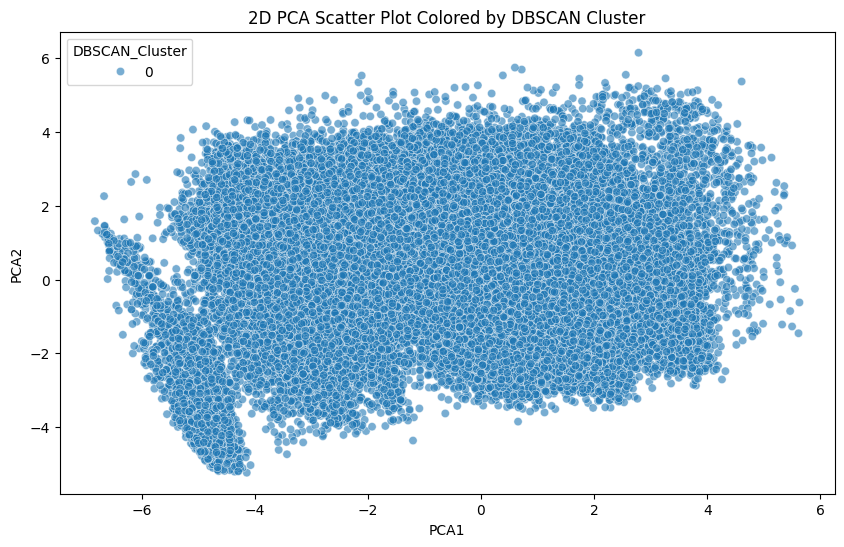

In [9]:

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="DBSCAN_Cluster", palette="tab10", alpha=0.6)
plt.title("2D PCA Scatter Plot Colored by DBSCAN Cluster")
plt.show()
